In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import confusion_matrix

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Transformacje danych

In [31]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))])

## CIFAR10 dataset

In [32]:
train_dataset = torchvision.datasets.CIFAR10(root='./data',train=True,download=True,transform=transform)
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

## Klasy

In [33]:
classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

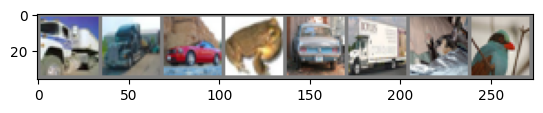

truck truck car frog car truck cat bird


In [34]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    # matplolib a torch (C, H, W) -> (H, W, C)
    plt.show()
dataiter = iter(train_loader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))
print(' '.join(classes[labels[j]] for j in range(8)))

## Definicja CNN

In [35]:
class CIFAR10CNN(nn.Module):
    def __init__(self):
        super(CIFAR10CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
        # self.dropout = nn.Dropout(0.2) # usuwanie losowo danych 
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        # x = self.dropout(x)
        x = self.fc2(x)
        return x

## Tworzenie modelu

In [36]:
model = CIFAR10CNN().to(device)

## Loss function i optimizer

In [37]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

## Training loop

In [38]:
# epochs = 10

# for epoch in tqdm(range(epochs)):
#     model.train()
#     running_loss = 0.0

#     for i, (images, labels) in enumerate(train_loader):
#         images = images.to(device)
#         labels = labels.to(device)
#         outputs = model(images)
#         optimizer.zero_grad()
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()

#         if i % 100 == 99:
#             print(
#                 f'Epoch {epoch+1}, '
#                 f'Batch {i+1}, '
#                 f'Loss: {running_loss / 100:.4f}')
#             running_loss = 0.0

In [39]:
# torch.save(model.state_dict(),'model_CNN_5.pth')

In [40]:
model = CIFAR10CNN().to(device)
model.load_state_dict(torch.load("model_CNN_30.pth", map_location=device))
model.eval()

CIFAR10CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

## Ewaluacja modelu

In [41]:
import torchmetrics.classification as mp
n_classes = 10
precision = mp.MulticlassPrecision(num_classes=n_classes,average='macro').to(device)
recall = mp.MulticlassRecall(num_classes=n_classes,average='macro').to(device)
f1 = mp.MulticlassF1Score(num_classes=n_classes,average='macro').to(device)
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        precision.update(predicted, labels)
        recall.update(predicted, labels)
        f1.update(predicted, labels)
accuracy = 100 * correct / total
precision_value = precision.compute().item()
recall_value = recall.compute().item()
f1_value = f1.compute().item()
print(f'Accuracy : {accuracy:.2f}%')
print(f'Precision: {precision_value:.4f}')
print(f'Recall   : {recall_value:.4f}')
print(f'F1-score : {f1_value:.4f}')

Accuracy : 70.74%
Precision: 0.7166
Recall   : 0.7074
F1-score : 0.7104


## Accuracy per klasa

In [42]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'{classname}: {accuracy:.2f}%')

plane: 72.90%
car: 75.50%
bird: 60.60%
cat: 58.20%
deer: 68.70%
dog: 58.80%
frog: 79.50%
horse: 76.50%
ship: 79.00%
truck: 77.70%


# ATAK

In [71]:
poczatek = 1
koniec = len(test_dataset)+1
indeksy = random.sample(range(poczatek, koniec), 5)
print(indeksy)
# indeksy = [3758, 9814, 3391, 4077, 2510]

[5685, 4583, 5979, 6214, 28]


In [72]:
def pokaz(img1, img2, title1=None, title2=None):
    img1 = img1.cpu().permute(1, 2, 0).clamp(0,1)
    img2 = img2.cpu().permute(1, 2, 0).clamp(0,1)
    fig, ax = plt.subplots(1, 2, figsize=(8,4))
    ax[0].imshow(img1)
    ax[0].set_title(title1)
    ax[1].imshow(img2)
    ax[1].set_title(title2)
    plt.show()

## BRUTEFORCE

In [73]:
import torch.nn.functional as F
def find_best_pixel(model, image, true_label, device):
    model.eval()
    image = image.to(device)
    best_score = float("-inf")
    best_x = 0
    best_y = 0
    best_image = None
    for y in range(32):
        for x in range(32):
            attacked = image.clone()
            attacked[:, y, x] = 1.0
            output = model(attacked.unsqueeze(0))
            probs = F.softmax(output, dim=1)
            true_confidence = probs[0, true_label].item()
            score = 1 - true_confidence
            if score > best_score:
                best_score = score
                best_x = x
                best_y = y
                best_image = attacked.clone()
    return best_x, best_y, best_score, best_image

In [74]:
true_labels = []
pred_after = []
model.eval()
for idx in indeksy:
    image, label = test_dataset[idx]
    x, y, score, attacked = find_best_pixel(model,image,label,device)
    with torch.no_grad():
        output_after = model(attacked.unsqueeze(0))
        probs_after = F.softmax(output_after,dim=1)
    prediction_after = (probs_after.argmax(dim=1).item())
    true_labels.append(label)
    pred_after.append(prediction_after)

In [75]:
true_labels = []
pred_before = []
pred_after = []
model.eval()
for idx in indeksy:
    image, label = test_dataset[idx]
    image = image.to(device)
    with torch.no_grad():
        output_before = model(image.unsqueeze(0))
        probs_before = F.softmax(output_before,dim=1)
    prediction_before = (probs_before.argmax(dim=1).item())
    x, y, score, attacked = find_best_pixel(model,image,label,device)
    with torch.no_grad():
        output_after = model(attacked.unsqueeze(0))
        probs_after = F.softmax(output_after,dim=1)
    prediction_after = (probs_after.argmax(dim=1).item())
    true_labels.append(label)
    pred_before.append(prediction_before)
    pred_after.append(prediction_after)

In [76]:
cm_before = confusion_matrix(true_labels,pred_before)
cm_after = confusion_matrix(true_labels,pred_after)

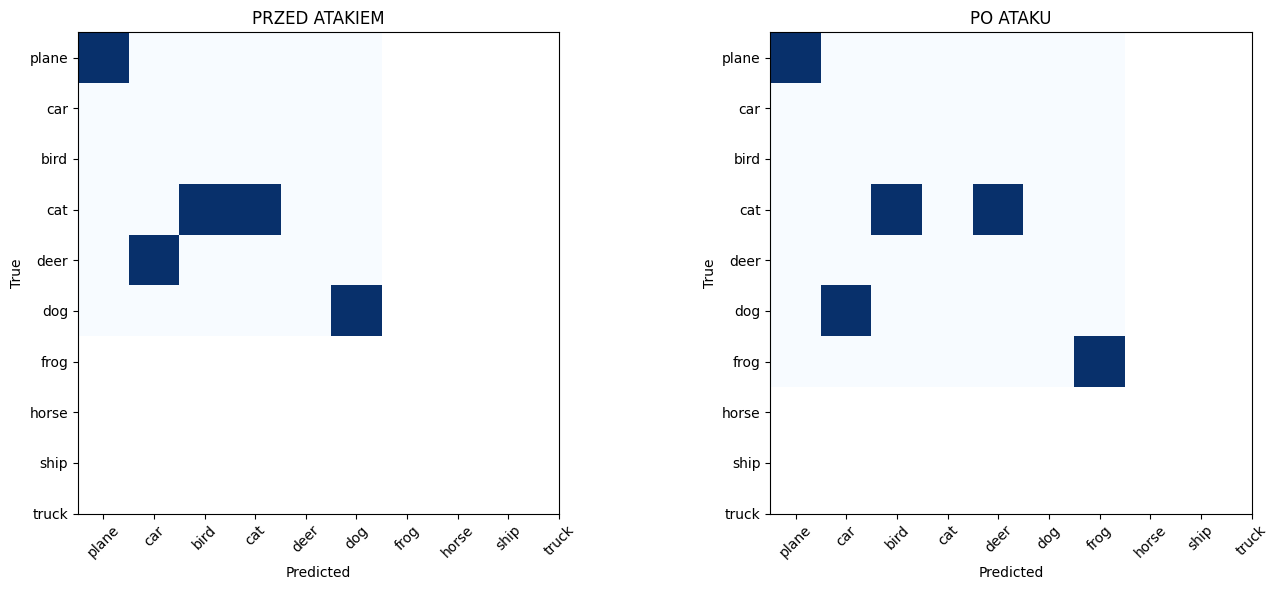

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
im1 = axes[0].imshow(cm_before,cmap='Blues')
axes[0].set_title("PRZED ATAKIEM")
axes[0].set_xticks(range(len(classes)))
axes[0].set_yticks(range(len(classes)))
axes[0].set_xticklabels(classes,rotation=45)
axes[0].set_yticklabels(classes)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
im2 = axes[1].imshow(cm_after,cmap='Blues')
axes[1].set_title("PO ATAKU")
axes[1].set_xticks(range(len(classes)))
axes[1].set_yticks(range(len(classes)))
axes[1].set_xticklabels(classes,rotation=45)
axes[1].set_yticklabels(classes)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
plt.tight_layout()
plt.show()

In [78]:
#heatmapa dla bruteforce
def heatmapa(model,image,label):
    model.eval()
    image = image.clone().detach()
    with torch.no_grad():
        output = model(
            image.unsqueeze(0))
        probs = F.softmax(output,dim=1)
    original_confidence = (
        probs[0,label].item())
    H,W = image.shape[1:]
    heatmap = torch.zeros(H,W)
    for y in range(H):
        for x in range(W):
            attacked = image.clone()
            attacked[:,y,x] = 1.0
            with torch.no_grad():
                output_after = model(attacked.unsqueeze(0))
                probs_after = F.softmax(output_after,dim=1)
            new_confidence = (probs_after[0,label].item())
            drop = (original_confidence- new_confidence)
            heatmap[y,x] = drop
    return heatmap


 index: 5685
LABEL:   car
PRZED:   car 1.0
PO:      car 0.9983307719230652


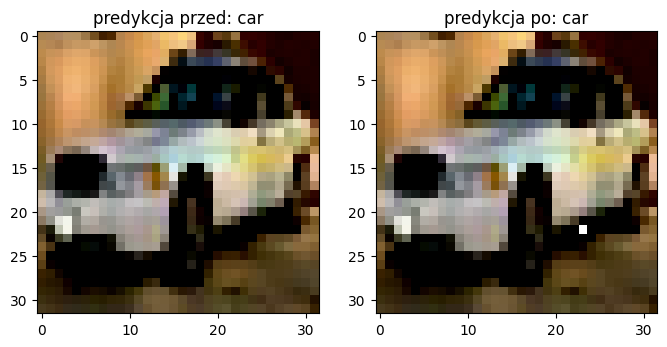


 index: 4583
LABEL:   horse
PRZED:   bird 0.8443431854248047
PO:      bird 0.9998075366020203


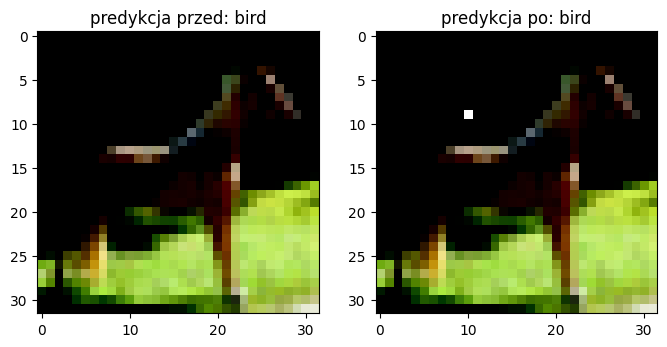


 index: 5979
LABEL:   dog
PRZED:   cat 0.8269190192222595
PO:      cat 0.9998663663864136


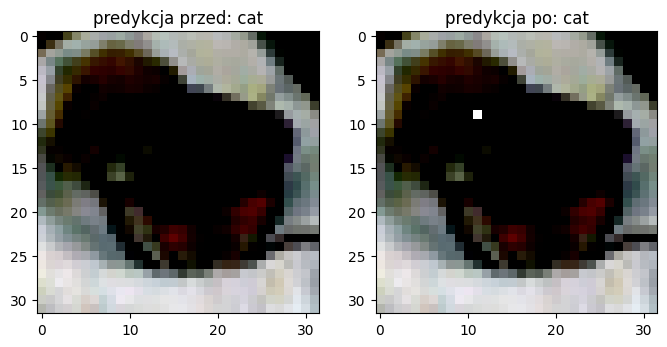


 index: 6214
LABEL:   dog
PRZED:   dog 0.9999603033065796
PO:      frog 0.9975812435150146


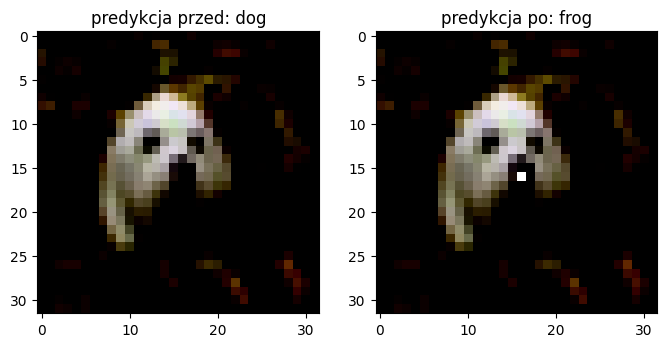


 index: 28
LABEL:   truck
PRZED:   truck 0.9999998807907104
PO:      truck 0.9988600015640259


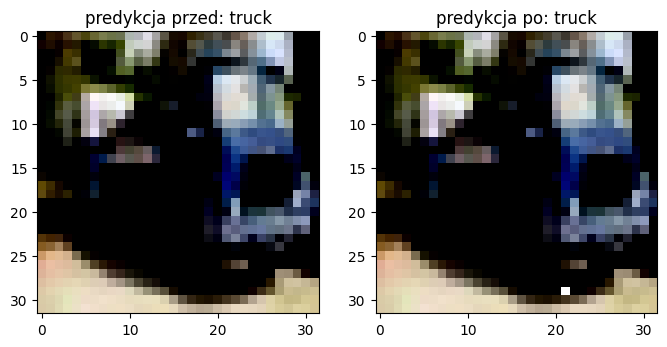

In [79]:
results = []
model.eval()
for idx in indeksy:
    print(f"\n index: {idx}")
    image, label = test_dataset[idx]
    model.eval()
    image_device = image.to(device)
    output = model(image_device.unsqueeze(0))
    probs = F.softmax(output, dim=1)
    prediction_before = probs.argmax(dim=1).item()
    confidence_before = probs[0, prediction_before].item()
    print("LABEL:  ",classes[label])
    print("PRZED:  ", classes[prediction_before], confidence_before)

    x, y, score, attacked = find_best_pixel(model,image,label,device)

    output_after = model(attacked.unsqueeze(0))
    probs_after = F.softmax(output_after, dim=1)
    prediction_after = probs_after.argmax(dim=1).item()
    confidence_after = probs_after[0, prediction_after].item()
    print("PO:     ",classes[prediction_after], confidence_after)

    # true_conf_before = probs[0, label].item()
    # true_conf_after = probs_after[0, label].item()
    # drop = true_conf_before - true_conf_after
    # print("drop: ",drop)

    # entropy = -(probs_after * probs_after.log()).sum().item()
    # print(entropy)
    
    pokaz(image, attacked, f"predykcja przed: {classes[prediction_before]}", f"predykcja po: {classes[prediction_after]}")

    # difference = (attacked - image).abs()
    # difference = difference / difference.max()
    # plt.imshow(difference.permute(1,2,0))
    # plt.show()

    # heatmap = heatmapa(model,image_device,label)
    # plt.figure(figsize=(6,6))
    # plt.imshow(heatmap.cpu(),cmap='hot')
    # plt.colorbar()
    # plt.show()



## GRADIENT

In [80]:
import torch
import torch.nn.functional as F
# największy lokalny wpływ na funkcję straty modelu
def gradient_attack(model, image, true_label, epsilon=1.0): # epsilon = 1 , widoczny atak
    model.eval()
    image = image.clone().detach()
    image.requires_grad = True
    output = model(image.unsqueeze(0))
    loss = F.cross_entropy(output,torch.tensor([true_label]).to(image.device))
    model.zero_grad()

    loss.backward() # liczy gradienty dla wszystkich parametrów jednocześnie
    grad = image.grad.data
    
    # importance = grad.abs().sum(dim=0)
    importance = torch.norm(grad, p=2, dim=0) # w teorii powinno lepiej działać
    y, x = torch.nonzero(importance == importance.max(),as_tuple=True)
    y = y.item()
    x = x.item()
    attacked = image.clone().detach()
    for c in range(3):
        attacked[c, y, x] += (epsilon * torch.sign(grad[c, y, x]))
    attacked = torch.clamp(attacked, -1, 1) # pilnuje zakresu
    return attacked, (x,y), grad


index: 5685
LABEL:  car
PRZED:  car 1.0
PO:     car 1.0


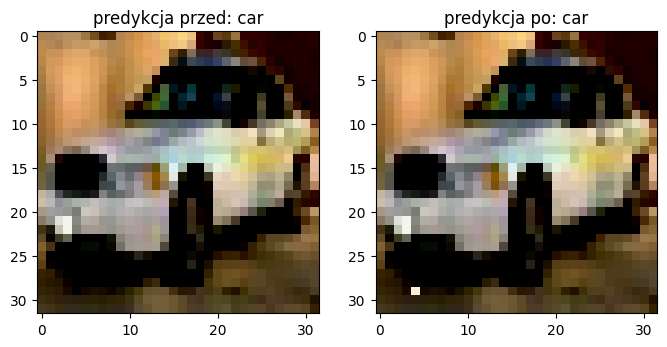


index: 4583
LABEL:  horse
PRZED:  bird 0.8443431854248047
PO:     bird 0.6900461316108704


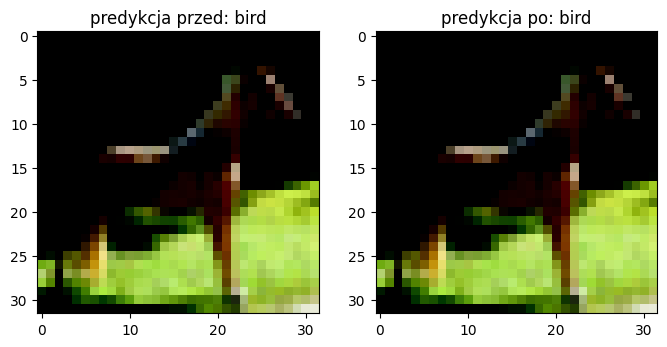


index: 5979
LABEL:  dog
PRZED:  cat 0.8269190192222595
PO:     dog 0.9505095481872559


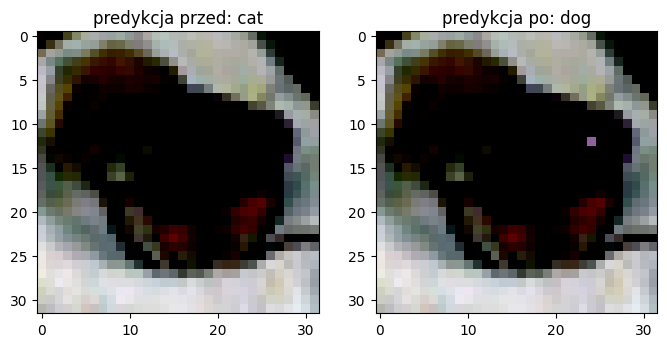


index: 6214
LABEL:  dog
PRZED:  dog 0.9999603033065796
PO:     frog 0.851231038570404


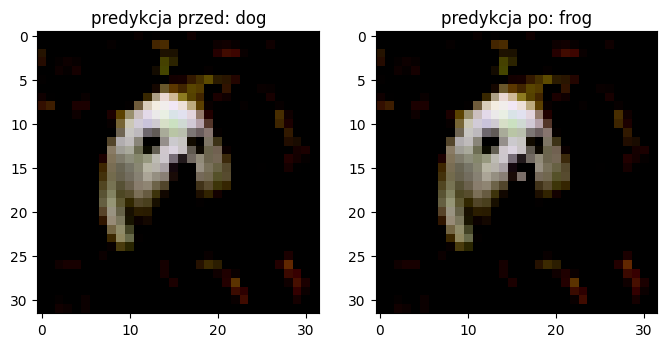


index: 28
LABEL:  truck
PRZED:  truck 0.9999998807907104
PO:     truck 0.9999998807907104


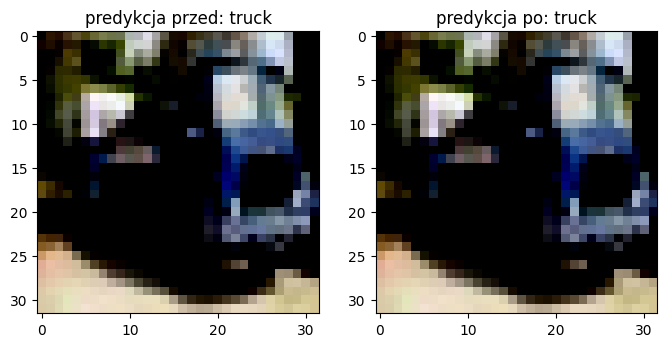

In [81]:
model.eval()
for idx in indeksy:
    print(f"\nindex: {idx}")
    image, label = test_dataset[idx]
    image_device = image.to(device)
    output = model(image_device.unsqueeze(0))
    probs = F.softmax(output, dim=1)
    prediction_before = probs.argmax(dim=1).item()
    confidence_before = probs[0, prediction_before].item()
    print("LABEL: ", classes[label])
    print("PRZED: ", classes[prediction_before], confidence_before)
    attacked, (x,y), grad = gradient_attack(model,image_device,label,epsilon=1.0)

    # print(f"Zmieniony piksel: ({x}, {y})")
    with torch.no_grad():
        output_after = model(attacked.unsqueeze(0))
        probs_after = F.softmax(output_after, dim=1)

    prediction_after = probs_after.argmax(dim=1).item()
    confidence_after = probs_after[0, prediction_after].item()
    
    print("PO:    ", classes[prediction_after], confidence_after)
    
    pokaz(image,attacked.cpu(),f"predykcja przed: {classes[prediction_before]}",f"predykcja po: {classes[prediction_after]}")

    # difference = (attacked - image).abs() #wskazanie zmienionego pixela
    # difference = difference / difference.max()
    # plt.imshow(difference.permute(1,2,0))
    # plt.show()

    # heatmap = torch.norm(grad,p=2,dim=0) # jasne miejsca - model bardzo czuły / ciemne - mało istotne pixele
    # plt.imshow(heatmap.cpu(),cmap='hot')
    # plt.colorbar()
    # plt.title("Gradient Heatmap")
    # plt.show()

In [82]:
true_labels = []
pred_before = []
pred_after = []
model.eval()
for idx in indeksy:
    image, label = test_dataset[idx]
    image = image.to(device)
    with torch.no_grad():
        output_before = model(image.unsqueeze(0))
        probs_before = F.softmax(output_before, dim=1)
    prediction_before = (probs_before.argmax(dim=1).item())
    attacked, (x,y), grad = gradient_attack(model,image,label,epsilon=1.0)
    with torch.no_grad():
        output_after = model(attacked.unsqueeze(0))
        probs_after = F.softmax(output_after,dim=1)
    prediction_after = (probs_after.argmax(dim=1).item())
    true_labels.append(label)
    pred_before.append(prediction_before)
    pred_after.append(prediction_after)

In [83]:
from sklearn.metrics import confusion_matrix
cm_before = confusion_matrix(true_labels,pred_before)
cm_after = confusion_matrix(true_labels,pred_after)

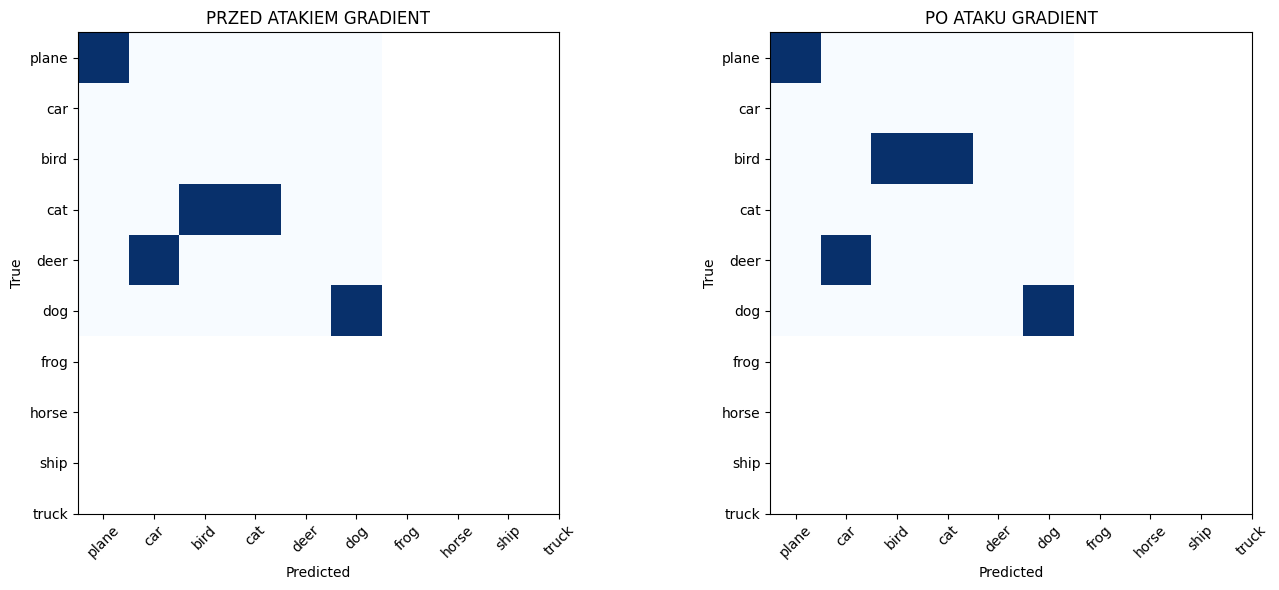

In [84]:
fig, axes = plt.subplots(1,2,figsize=(14,6))
im1 = axes[0].imshow(cm_before,cmap='Blues')
axes[0].set_title("PRZED ATAKIEM GRADIENT")
axes[0].set_xticks(range(len(classes)))
axes[0].set_yticks(range(len(classes)))
axes[0].set_xticklabels(classes,rotation=45)
axes[0].set_yticklabels(classes)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

im2 = axes[1].imshow(cm_after,cmap='Blues')
axes[1].set_title("PO ATAKU GRADIENT")
axes[1].set_xticks(range(len(classes)))
axes[1].set_yticks( range(len(classes)))
axes[1].set_xticklabels(classes,rotation=45)
axes[1].set_yticklabels(classes)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
plt.tight_layout()
plt.show()